# Homework 6: Decision Transformer with Memory for POMDPs


Ссылка на репозиторий: https://github.com/Nonvisedarte/Decision-Transformer-with-Memory-for-POMDPs

В задании рассматривается Offline RL постановка: сначала собирается датасет траекторий с помощью PPO-GRU агента, затем Decision Transformer обучается предсказывать действия по последовательности return-to-go, состояний и действий.

Основная среда — `VelocityCartPoleEnv`. Это POMDP-версия CartPole, где velocity-переменные скрыты из наблюдения. Поэтому агент должен восстанавливать динамику системы из истории наблюдений. Стандартный Decision Transformer может использовать self-attention внутри context window, но explicit memory modules могут хранить информацию за пределами текущего transformer context и потенциально улучшать устойчивость.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

## 1. Dataset statistics

Сначала посмотрим статистику offline dataset. Датасет был собран с помощью PPO-GRU агента и затем использовался для обучения Decision Transformer моделей.

Так как это Offline RL, качество датасета сильно влияет на итоговое поведение модели: Decision Transformer учится имитировать действия из уже собранных траекторий, conditioned on return-to-go.

In [2]:
with open("results/dataset_stats_velocity_cartpole.txt", "r", encoding="utf-16") as f:
    dataset_stats = f.read()

print(dataset_stats)

Analyzing 100 trajectories files in pomdp_datasets/velocity_cartpole

Dataset statistics:
Total episodes: 100
Total steps: 49847
Mean reward per episode: 498.47
Median reward per episode: 500.00
Min/Max reward: 476.00/500.00
Reward std: 4.66
Mean episode length: 498.47
Reward percentiles: 
  10%: 494.80
  25%: 500.00
  50%: 500.00
  75%: 500.00
  90%: 500.00
  95%: 500.00
  99%: 500.00
Saved histogram to plots/velocity_cartpole_rewards_histogram.png



Полученная статистика показывает, что датасет содержит в основном успешные траектории: среднее значение return составляет 498.47 при максимальном возможном значении 500, а медиана равна 500. Это указывает на то, что большинство эпизодов демонстрирует почти оптимальное поведение.

Это важно учесть при анализе дальнейших результатов. Поскольку полный датасет уже содержит траектории высокого качества, различные модели могут показывать близкое к оптимальному поведение, и различия между ними могут быть незначительными. Поэтому для более детального сравнения подходов рассматриваются дополнительные эксперименты: уменьшение размера обучающего датасета, изменение длины context window, анализ влияния RTG и динамики обучения.

Ниже показана гистограмма rewards по эпизодам в offline dataset.

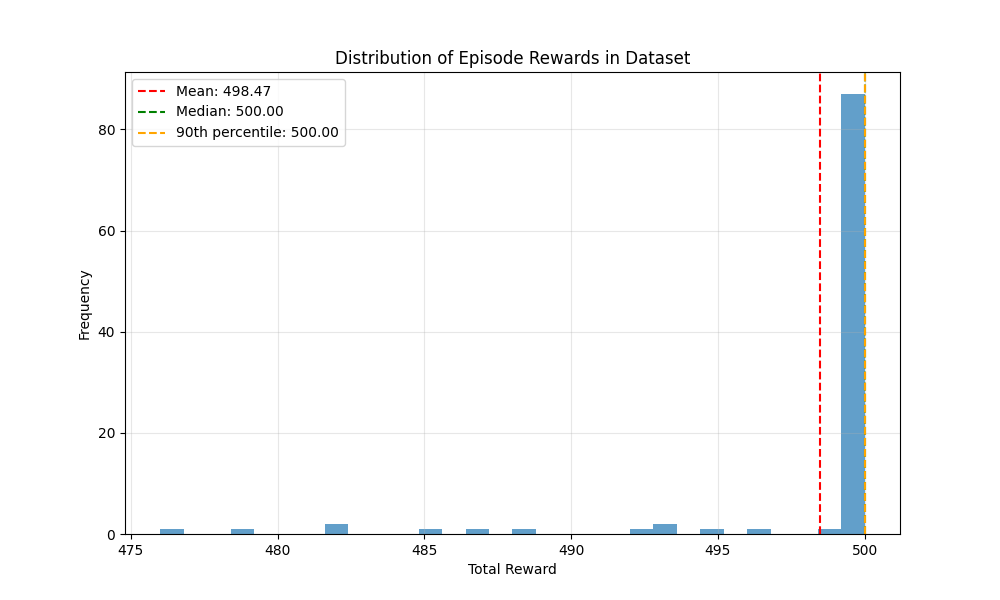

In [3]:
display(Image(filename="results/final_plots/velocity_cartpole_rewards_histogram.png"))

По гистограмме видно, что большинство траекторий имеет reward, близкий к максимальному значению 500. Это подтверждает, что датасет в основном состоит из успешных траекторий, а небольшое количество эпизодов с меньшим return является скорее исключением.

## 2. Изменения шаблона

Внесено несколько изменений в шаблон. Они не меняют саму постановку задачи, но делают обучение и evaluation более корректными.

### 2.1. Порядок токенов Decision Transformer

Формирование последовательности токенов приведено к стандартной DT-логике:

$$ (R_t,\ s_t,\ a_t) $$

На каждом временном шаге вход модели формируется в фиксированном порядке: сначала подаётся return-to-go, затем состояние и соответствующее действие. Такой порядок важен, поскольку transformer обучается на последовательности токенов и использует их относительное положение для построения временного контекста и предсказания следующего действия.

### 2.2. Success rate

Был уточнён расчёт success rate на этапе evaluation. Теперь успешность фиксируется на уровне всего эпизода, а не на каждом шаге внутри step loop.

### 2.3. Построение trajectory windows

Было изменено формирование training windows в POMDPDataset. Теперь каждое окно строится только внутри одной trajectory и не может пересекать границу между разными episodes.
Это важно, поскольку объединение конца одной trajectory с началом другой создаёт искусственную последовательность, которая не встречалась в среде. В результате модель могла бы обучаться на некорректном temporal context. Предварительное построение списка валидных окон гарантирует, что каждый training sample соответствует реальному фрагменту одного episode.

### 2.4. Настраиваемый target return-to-go

Была добавлена возможность явно задавать значение `target_return` на этапе evaluation с помощью аргумента `--target_return`. Это позволяет использовать один уже обученный checkpoint и анализировать, как меняется поведение модели при разных returns.

В экспериментах рассматриваются значения target return 420, 450, 480 и 500. Переобучение модели для каждого значения не требуется, поскольку return-to-go является частью входной последовательности Decision Transformer, а не отдельным обучаемым параметром.

## 3. Custom memory: Temporal Difference Memory (TDM)

Помимо стандартных GRU и LSTM, реализован кастомный механизм памяти: **Temporal Difference Memory (TDM)**.

Идея TDM связана со спецификой `VelocityCartPoleEnv`. В этой среде агент не видит скорость тележки и угловую скорость шеста. Но эти величины можно приблизительно понять по тому, как меняются наблюдаемые координаты от шага к шагу.

Например, если положение тележки сильно изменилось между двумя соседними шагами, значит тележка движется быстро. Если угол шеста быстро меняется, значит угловая скорость тоже большая.

Поэтому TDM хранит не просто информацию о прошлых состояниях, а информацию о том, **как состояние меняется во времени**.

### 3.1. Основная идея

Сначала observation проходит через линейный `state_encoder`, и получается embedding состояния:

$$ e_t $$

TDM сравнивает текущий embedding с предыдущим:

$$ d_t = e_t - e_{t-1} $$

Эта разность показывает, насколько сильно изменилось состояние между двумя соседними шагами. Именно такая информация полезна в среде, где скорости скрыты.

Затем difference vector проходит через обучаемый слой:

$$ z_t = \tanh(W_{\Delta} d_t) $$

Так модель сама учится выбирать, какие изменения состояния важны для выбора действия.

### 3.2. Обновление памяти

TDM поддерживает memory state:

$$ m_t $$

Он обновляется через экспоненциальное сглаживание:

$$ m_t = \alpha m_{t-1} + (1 - \alpha) z_t $$

где:

$$ \alpha = \text{tdm\_decay} $$

Если `tdm_decay` большой, память меняется медленно и сильнее сохраняет прошлую информацию. Если `tdm_decay` меньше, память быстрее реагирует на новые изменения.

Сначала я использовал `tdm_decay = 0.9`, но такая память оказалась слишком медленной. Она хорошо работала при длинном context, но хуже при context length 20. Поэтому был также проведён эксперимент с `tdm_decay = 0.7`. 

### 3.3. Как TDM используется в Decision Transformer

После обновления memory state он проецируется обратно в размерность transformer embedding:

$$ h_t = W_m m_t $$

Затем этот memory signal добавляется к state embedding:

$$ e'_t = e_t + h_t $$

Дальше модель использует `e'_t` вместо исходного `e_t` при формировании токена state.

Важно, что TDM не меняет сам transformer и не заменяет self-attention. Transformer-блоки остаются такими же, как в обычном Decision Transformer. TDM только дополняет представление состояния информацией о недавних изменениях наблюдений.

### 3.4. Почему это подходит для VelocityCartPole

В `VelocityCartPoleEnv` можно приблизительно оценить скрытые значения скоростей из разностей соседних наблюдений:

$$ velocity \approx position_t - position_{t-1} $$

$$ angular\ velocity \approx angle_t - angle_{t-1} $$

TDM использует ту же идею, но не на исходных координатах, а после `state_encoder`. Поскольку `state_encoder` является линейным слоем, разность embeddings можно интерпретировать как обучаемое преобразование разности исходных наблюдений:

$$ W s_t - W s_{t-1} = W(s_t - s_{t-1}) $$

То есть TDM помогает модели использовать информацию о том, как быстро меняются наблюдаемые координаты.

### 3.5. Отличие от GRU и LSTM

GRU и LSTM являются универсальными recurrent memory modules. Они могут хранить сложную информацию о прошлом, но их внутренняя логика менее прозрачна.

TDM проще и более специализирована:

- GRU/LSTM учатся запоминать произвольную информацию из последовательности;
- TDM явно использует изменения между соседними состояниями;
- TDM проще интерпретировать;
- качество TDM заметно зависит от параметра `tdm_decay`.

TDM обучался вместе с Decision Transformer end-to-end. Отдельный loss для памяти не используется. Как и остальные модели, она обучена предсказывать действия из offline trajectories по return-to-go, states и actions.

## 4. Загрузка финальных результатов

In [4]:
context = pd.read_csv("results/final_context_ablation_summary.csv")
dataset_size = pd.read_csv("results/final_dataset_size_ablation_summary.csv")
rtg = pd.read_csv("results/final_rtg_ablation_summary.csv")
tdm_decay = pd.read_csv("results/final_tdm_decay_ablation_summary.csv")
training = pd.read_csv("results/final_training_dynamics_summary.csv")

print("context:", context.shape)
print("dataset_size:", dataset_size.shape)
print("rtg:", rtg.shape)
print("tdm_decay:", tdm_decay.shape)
print("training:", training.shape)

context: (16, 26)
dataset_size: (12, 27)
rtg: (16, 26)
tdm_decay: (4, 26)
training: (28, 19)


In [5]:
context.head()

,run_name,env,memory_type,context_length,seed,n_epochs,batch_size,n_embed,n_layer,n_head,...,std_return,min_return,max_return,success_rate,mean_length,std_length,run_dir,eval_rtg_mode,tdm_decay,model_label
0,none_ctx5_seed123,velocity_cartpole,none,5,123,7,64,64,3,4,...,0.000000,500.0,500.0,1.00,500.00,0.000000,results\runs\none_ctx5_seed123,constant,NaN,none
1,none_ctx10_seed123,velocity_cartpole,none,10,123,7,64,64,3,4,...,0.000000,500.0,500.0,1.00,500.00,0.000000,results\runs\none_ctx10_seed123,constant,NaN,none
2,baseline_none_seed123,velocity_cartpole,none,20,123,7,64,64,3,4,...,0.000000,500.0,500.0,1.00,500.00,0.000000,results\runs\baseline_none_seed123,constant,NaN,none
3,none_ctx50_seed123,velocity_cartpole,none,50,123,7,64,64,3,4,...,237.225731,11.0,500.0,0.50,271.95,237.225731,results\runs\none_ctx50_seed123,constant,NaN,none
4,gru_ctx5_seed123,velocity_cartpole,gru,5,123,7,64,64,3,4,...,59.376426,301.0,500.0,0.85,458.80,59.376426,results\runs\gru_ctx5_seed123,constant,NaN,gru


In [6]:
dataset_size.head()

,run_name,env,memory_type,context_length,seed,n_epochs,batch_size,n_embed,n_layer,n_head,...,min_return,max_return,success_rate,mean_length,std_length,run_dir,eval_rtg_mode,tdm_decay,model_label,data_size
0,none_data25_seed123,velocity_cartpole,none,20,123,7,64,64,3,4,...,8.0,11.0,0.0,9.30,0.900000,results\runs\none_data25_seed123,constant,NaN,none,25%
1,none_data50_seed123,velocity_cartpole,none,20,123,7,64,64,3,4,...,10.0,127.0,0.0,17.85,25.692947,results\runs\none_data50_seed123,constant,NaN,none,50%
2,baseline_none_seed123,velocity_cartpole,none,20,123,7,64,64,3,4,...,500.0,500.0,1.0,500.00,0.000000,results\runs\baseline_none_seed123,constant,NaN,none,100%
3,gru_data25_seed123,velocity_cartpole,gru,20,123,7,64,64,3,4,...,15.0,500.0,0.9,467.30,110.090917,results\runs\gru_data25_seed123,constant,NaN,gru,25%
4,gru_data50_seed123,velocity_cartpole,gru,20,123,7,64,64,3,4,...,13.0,500.0,0.8,426.10,150.903578,results\runs\gru_data50_seed123,constant,NaN,gru,50%


In [7]:
rtg.head()

,run_name,env,memory_type,context_length,seed,n_epochs,batch_size,n_embed,n_layer,n_head,...,std_return,min_return,max_return,success_rate,mean_length,std_length,run_dir,eval_rtg_mode,tdm_decay,model_label
0,none_rtg420_seed123,velocity_cartpole,none,20,123,10,64,64,3,4,...,10.561250,441.0,472.0,0.7,456.60,10.561250,results\runs\none_rtg420_seed123,constant,NaN,none
1,none_rtg450_seed123,velocity_cartpole,none,20,123,10,64,64,3,4,...,11.569788,473.0,500.0,1.0,486.80,11.569788,results\runs\none_rtg450_seed123,constant,NaN,none
2,none_rtg480_seed123,velocity_cartpole,none,20,123,10,64,64,3,4,...,3.482456,487.0,500.0,1.0,498.85,3.482456,results\runs\none_rtg480_seed123,constant,NaN,none
3,baseline_none_seed123,velocity_cartpole,none,20,123,7,64,64,3,4,...,0.000000,500.0,500.0,1.0,500.00,0.000000,results\runs\baseline_none_seed123,constant,NaN,none
4,gru_rtg420_seed123,velocity_cartpole,gru,20,123,10,64,64,3,4,...,3.468069,469.0,483.0,1.0,475.15,3.468069,results\runs\gru_rtg420_seed123,constant,NaN,gru


In [8]:
model_order = ["none", "gru", "lstm", "tdm decay=0.7"]

markers = {
    "none": "o",
    "gru": "s",
    "lstm": "^",
    "tdm decay=0.7": "D",
}

line_styles = {
    "none": "-",
    "gru": "--",
    "lstm": "-.",
    "tdm decay=0.7": ":",
}

x_offsets = {
    "none": -0.06,
    "gru": -0.02,
    "lstm": 0.02,
    "tdm decay=0.7": 0.06,
}

def plot_lines(
    df,
    x_col,
    y_col,
    title,
    ylabel,
    percent=False,
    use_offset=False,
    figsize=(9, 5),
):
    plt.figure(figsize=figsize)

    for model in model_order:
        sub = df[df["model_label"] == model].sort_values(x_col)
        if sub.empty:
            continue

        x = sub[x_col].astype(float)
        if use_offset:
            x = x + x_offsets.get(model, 0.0)

        y = sub[y_col].astype(float)
        if percent:
            y = y * 100

        plt.plot(
            x,
            y,
            marker=markers.get(model, "o"),
            linestyle=line_styles.get(model, "-"),
            linewidth=2,
            markersize=6,
            label=model,
        )

    plt.xlabel(x_col)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()

    if percent:
        plt.ylim(0, 105)

    plt.tight_layout()
    plt.show()

def plot_grouped_bars(df, x_col, y_col, x_order, title, ylabel, percent=False):
    fig, ax = plt.subplots(figsize=(9, 5))
    width = 0.18
    xs = list(range(len(x_order)))
    offsets = [(i - (len(model_order) - 1) / 2) * width for i in range(len(model_order))]

    for i, model in enumerate(model_order):
        vals = []
        for x in x_order:
            sub = df[(df[x_col] == x) & (df["model_label"] == model)]
            if sub.empty:
                vals.append(float("nan"))
            else:
                value = float(sub.iloc[-1][y_col])
                if percent:
                    value *= 100
                vals.append(value)

        bars = ax.bar([p + offsets[i] for p in xs], vals, width=width, label=model)

        for bar, value in zip(bars, vals):
            if pd.isna(value):
                continue
            if value == 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    1,
                    "0%",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=90,
                )

    ax.set_xticks(xs)
    ax.set_xticklabels([str(x) for x in x_order])
    ax.set_xlabel(x_col)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y")
    if percent:
        ax.set_ylim(0, 105)
    ax.legend()
    plt.show()

## 5. Графики обучения

Сначала сравним процесс обучения для четырёх основных моделей при стандартной настройке `context_length = 20` и полном датасете.

Сравниваются модели:

- стандартный DT без явной памяти (`none`)
- DT+GRU
- DT+LSTM
- DT+TDM с `tdm_decay = 0.7`

Здесь важно не только финальное качество, но и скорость сходимости: насколько быстро модель достигает высокого return и стабильного success rate.

In [9]:
training[["model_label", "epoch", "train_loss", "val_loss", "eval_mean_return", "eval_success_rate"]].head(20)

,model_label,epoch,train_loss,val_loss,eval_mean_return,eval_success_rate
0,none,1,0.593423,0.461905,401.9,0.7
1,none,2,0.462396,0.440958,497.6,1.0
2,none,3,0.453555,0.443448,498.4,1.0
3,none,4,0.450056,0.441171,500.0,1.0
4,none,5,0.447703,0.437854,500.0,1.0
5,none,6,0.445924,0.437409,500.0,1.0
6,none,7,0.444962,0.437087,499.6,1.0
7,gru,1,0.603913,0.490509,54.2,0.0
8,gru,2,0.461486,0.438171,500.0,1.0
9,gru,3,0.445126,0.442885,500.0,1.0


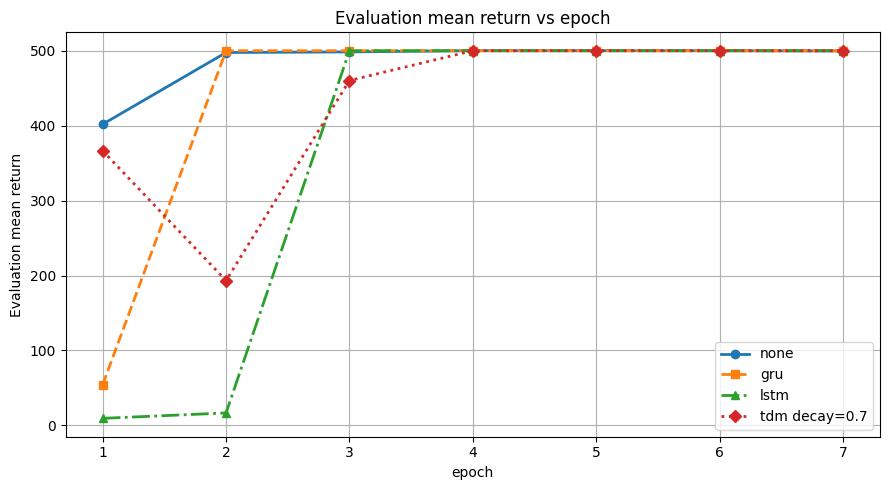

In [10]:
plot_lines(
    training,
    x_col="epoch",
    y_col="eval_mean_return",
    title="Evaluation mean return vs epoch",
    ylabel="Evaluation mean return",
    use_offset=False
)

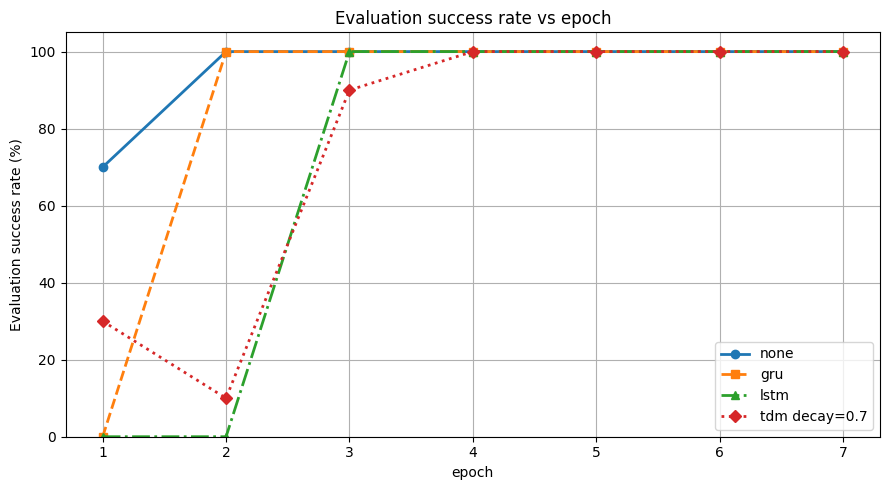

In [11]:
plot_lines(
    training,
    x_col="epoch",
    y_col="eval_success_rate",
    title="Evaluation success rate vs epoch",
    ylabel="Evaluation success rate (%)",
    percent=True,
    use_offset=False,
)

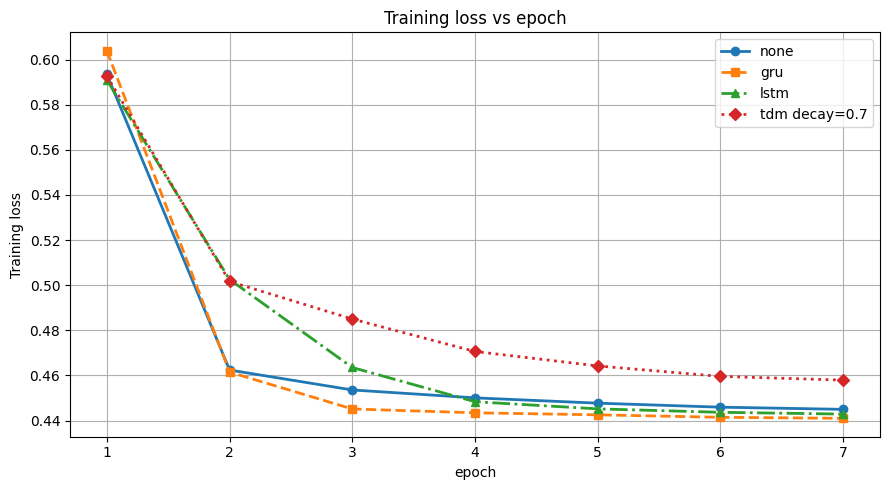

In [12]:
plot_lines(
    training,
    x_col="epoch",
    y_col="train_loss",
    title="Training loss vs epoch",
    ylabel="Training loss",
    use_offset=False,
)

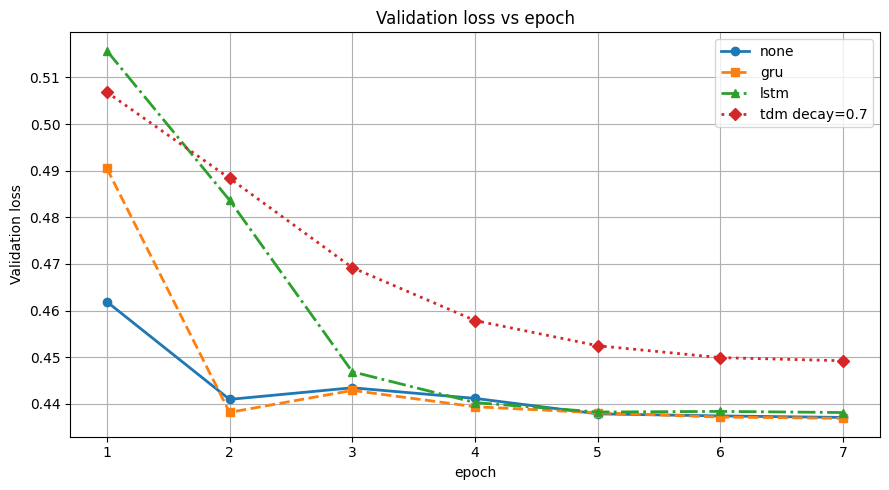

In [13]:
plot_lines(
    training,
    x_col="epoch",
    y_col="val_loss",
    title="Validation loss vs epoch",
    ylabel="Validation loss",
    use_offset=False,
)

По графикам обучения видно, что все четыре модели в итоге достигают максимального среднего return и 100% success rate, но делают это с разной скоростью. Стандартный DT (`none`) и DT+GRU обучаются быстрее всего: уже ко 2-й эпохе они достигают return 500 и 100% success rate. LSTM начинает хуже, но к 3-й эпохе резко улучшается и тоже выходит на максимальное качество. TDM с `decay=0.7` обучается немного медленнее: в первые эпохи качество нестабильно, но к 4-й эпохе она также достигает оптимального результата. Графики train loss и validation loss показывают, что ошибка предсказания действий постепенно уменьшается у всех моделей. При этом у TDM loss остаётся выше, чем у остальных моделей, даже когда return уже достигает 500. Это означает, что меньшая ошибка предсказания действий не всегда напрямую соответствует лучшему управлению средой. 

В целом, GRU показывает самую быструю и стабильную сходимость среди моделей с памятью. LSTM требует немного больше эпох, а TDM после настройки `decay` достигает такого же финального качества, но её обучение менее ровное на первых эпохах.

## 6. Влияние длины context window

В этом эксперименте менялась длина context window: 5, 10, 20 и 50. Это важно для POMDP, потому что при коротком окне модель видит меньше истории наблюдений.

In [14]:
context[
    ["model_label", "context_length", "mean_return", "std_return", "success_rate"]
].sort_values(["context_length", "model_label"])

,model_label,context_length,mean_return,std_return,success_rate
4,gru,5,458.80,59.376426,0.85
8,lstm,5,451.15,146.217398,0.90
0,none,5,500.00,0.000000,1.00
12,tdm decay=0.7,5,106.85,36.121012,0.00
5,gru,10,500.00,0.000000,1.00
9,lstm,10,500.00,0.000000,1.00
1,none,10,500.00,0.000000,1.00
13,tdm decay=0.7,10,491.75,35.278712,0.95
6,gru,20,500.00,0.000000,1.00
10,lstm,20,500.00,0.000000,1.00


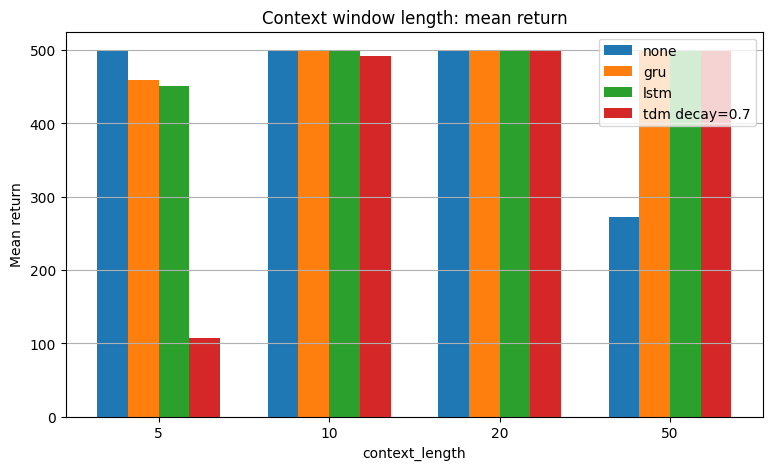

In [15]:
plot_grouped_bars(
    context,
    x_col="context_length",
    y_col="mean_return",
    x_order=[5, 10, 20, 50],
    title="Context window length: mean return",
    ylabel="Mean return",
)

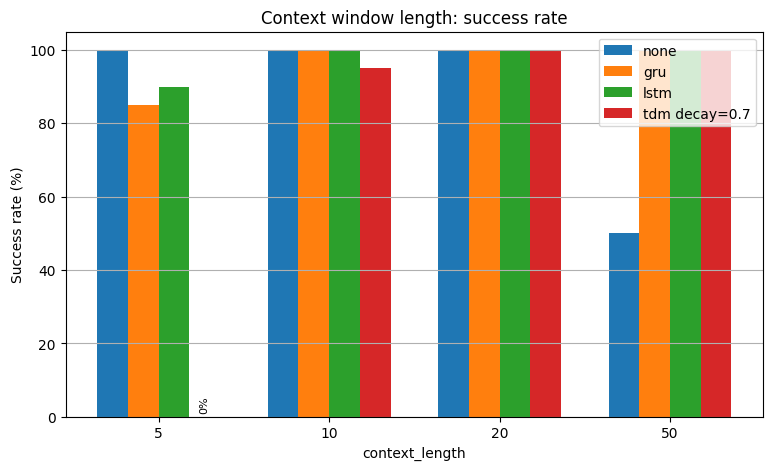

In [16]:
plot_grouped_bars(
    context,
    x_col="context_length",
    y_col="success_rate",
    x_order=[5, 10, 20, 50],
    title="Context window length: success rate",
    ylabel="Success rate (%)",
    percent=True,
)

По результатам видно, что большинство моделей хорошо решают задачу уже при небольшом контекстном окне.

Стандартный DT (`none`) неожиданно показывает идеальный результат при context length 5, 10 и 20, но резко деградирует при context length 50: mean return падает до 271.95, а success rate до 50%. Это может быть связано с тем, что более длинная последовательность усложняет обучение transformer без явной памяти.

GRU и LSTM работают наиболее стабильно: начиная с context length 10 обе модели достигают максимального return 500 и 100% success rate. При context length 5 качество немного ниже, но всё ещё достаточно высокое.

TDM с `tdm_decay=0.7` плохо работает при context length 5, но резко улучшается уже при context length 10 и достигает максимального качества при context length 20 и 50. Это показывает, что TDM нужна хотя бы небольшая история наблюдений, чтобы полезно использовать изменения между соседними состояниями.

В целом, стандартный DT, GRU/LSTM и TDM по-разному реагируют на изменение context length. GRU и LSTM оказались наиболее стабильными, стандартный DT неожиданно ухудшился при слишком длинном context, а TDM оказалась чувствительной к слишком короткому context.

## 7. Влияние размера датасета

В этом эксперименте проверяется, как модели зависят от количества offline данных. Используются 25%, 50% и 100% trajectories при фиксированном `context_length = 20`.

Этот эксперимент важен, потому что в Offline RL качество и объём датасета напрямую влияют на то, насколько хорошо модель может выучить поведение.

In [17]:
dataset_size[
    ["model_label", "data_size", "mean_return", "std_return", "success_rate"]
].sort_values(["data_size", "model_label"])

,model_label,data_size,mean_return,std_return,success_rate
5,gru,100%,500.00,0.000000,1.00
8,lstm,100%,500.00,0.000000,1.00
2,none,100%,500.00,0.000000,1.00
11,tdm decay=0.7,100%,500.00,0.000000,1.00
3,gru,25%,467.30,110.090917,0.90
6,lstm,25%,492.55,32.473797,0.95
0,none,25%,9.30,0.900000,0.00
9,tdm decay=0.7,25%,500.00,0.000000,1.00
4,gru,50%,426.10,150.903578,0.80
7,lstm,50%,465.90,112.235868,0.90


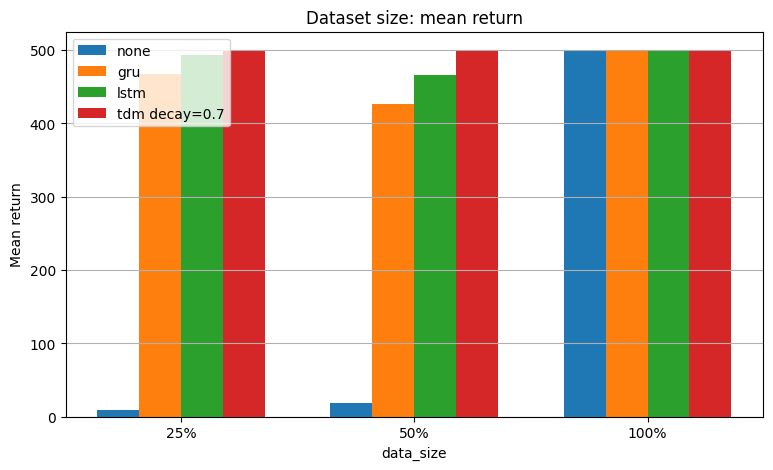

In [18]:
plot_grouped_bars(
    dataset_size,
    x_col="data_size",
    y_col="mean_return",
    x_order=["25%", "50%", "100%"],
    title="Dataset size: mean return",
    ylabel="Mean return",
)

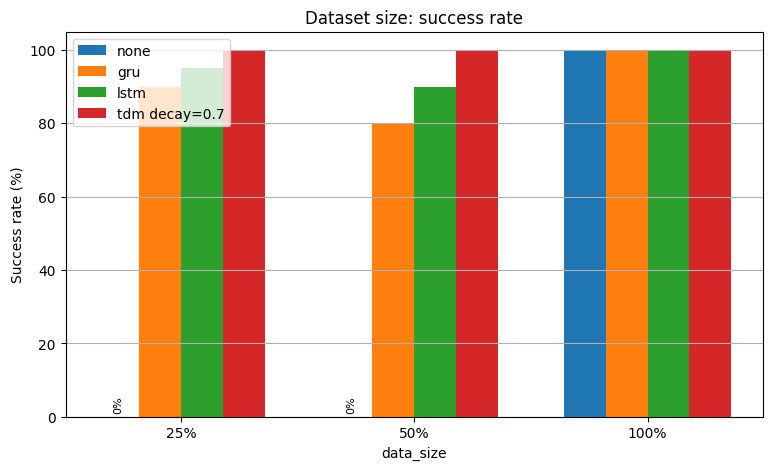

In [19]:
plot_grouped_bars(
    dataset_size,
    x_col="data_size",
    y_col="success_rate",
    x_order=["25%", "50%", "100%"],
    title="Dataset size: success rate",
    ylabel="Success rate (%)",
    percent=True,
)

При уменьшении размера датасета различия между моделями становятся намного заметнее.

Стандартный DT без явной памяти (`none`) плохо решает задачу при 25% и 50% данных: mean return остаётся очень низким, а success rate равен 0%. При этом при полном датасете эта модель достигает максимального качества.

GRU и LSTM значительно устойчивее к уменьшению датасета. Даже на 25% данных они показывают высокий return и высокий success rate. LSTM в этих экспериментах немного стабильнее GRU: при 25% и 50% данных она даёт более высокий return и success rate.

TDM с `tdm_decay=0.7` показывает лучший результат среди всех моделей на уменьшенном датасете: она достигает return 500 и 100% success rate уже на 25% данных. Это говорит о том, что корректно настроенная TDM хорошо использует информацию об изменениях состояния и может быть очень эффективной при ограниченном количестве offline данных.

В целом, этот эксперимент показывает, что явная память особенно полезна, когда данных мало. Стандартный DT справляется только на полном датасете, а GRU, LSTM и TDM остаются намного более устойчивыми при уменьшении числа trajectories.

## 8. Влияние target return-to-go

Decision Transformer отличается от обычной policy тем, что получает на вход не только состояния и прошлые действия, но и **return-to-go** (сколько награды модель ещё должна получить дальше).

Поэтому можно взять один уже обученный checkpoint и во время evaluation менять `target_return`, чтобы проверить, насколько поведение модели зависит от желаемого return - использует ли модель этот сигнал или почти игнорирует его.

В этом эксперименте используются значения `target_return`: 420, 450, 480 и 500 при фиксированном `context_length = 20`.

Переобучение для каждого значения не требуется, потому что return-to-go является входом модели, а не отдельным обучаемым параметром.

In [20]:
rtg[
    ["model_label", "target_return", "mean_return", "std_return", "success_rate"]
].sort_values(["target_return", "model_label"])

,model_label,target_return,mean_return,std_return,success_rate
4,gru,420.0,475.15,3.468069,1.00
8,lstm,420.0,500.00,0.000000,1.00
0,none,420.0,456.60,10.561250,0.70
12,tdm decay=0.7,420.0,458.50,5.835238,0.95
5,gru,450.0,498.75,2.255549,1.00
9,lstm,450.0,500.00,0.000000,1.00
1,none,450.0,486.80,11.569788,1.00
13,tdm decay=0.7,450.0,487.35,5.632717,1.00
6,gru,480.0,500.00,0.000000,1.00
10,lstm,480.0,500.00,0.000000,1.00


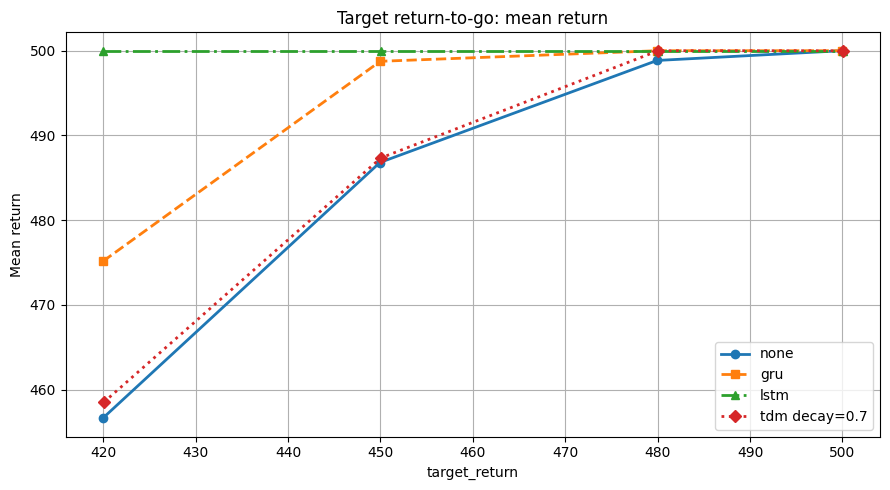

In [21]:
plot_lines(
    rtg,
    x_col="target_return",
    y_col="mean_return",
    title="Target return-to-go: mean return",
    ylabel="Mean return",
    use_offset=True,
)

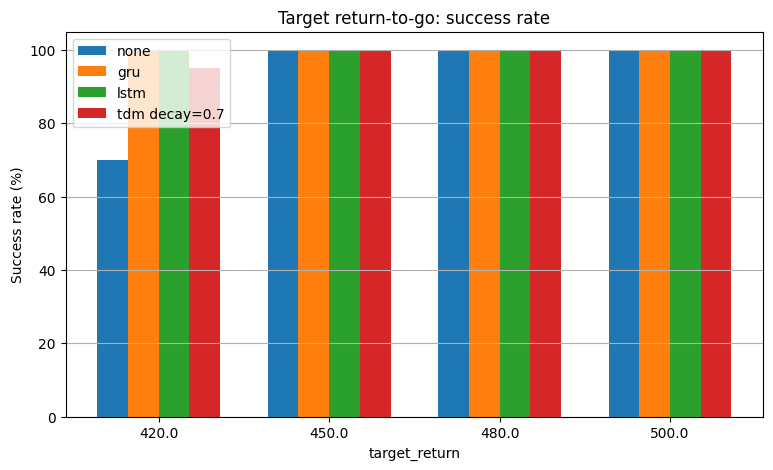

In [22]:
plot_grouped_bars(
    rtg,
    x_col="target_return",
    y_col="success_rate",
    x_order=[420.0, 450.0, 480.0, 500.0],
    title="Target return-to-go: success rate",
    ylabel="Success rate (%)",
    percent=True,
)

По данному эксперименту видно, что все модели достигают почти максимального return при `target_return` 450 и выше. Это ожидаемо для CartPole: если модель умеет хорошо управлять средой, ей выгодно держать шест как можно дольше, даже если заданный target return немного ниже максимума.

При самом низком значении `target_return = 420` различия становятся заметнее. Стандартный DT (`none`) падает до mean return около 457 и success rate 70%. GRU показывает более высокий return около 475 и 100% success rate. LSTM остаётся полностью стабильной и сохраняет return 500 при всех значениях target return.

TDM с `tdm_decay=0.7` ведёт себя близко к стандартному DT по mean return при `target_return = 420`, но имеет более высокий success rate: 95% против 70%. При target return 450 и выше TDM также достигает почти максимального качества.

В целом, эксперимент показывает, что `target_return` влияет на поведение моделей только при достаточно низком значении. При `target_return = 420` часть моделей становится менее стабильной, но при 450, 480 и 500 почти все модели удерживают шест до максимальной длины эпизода. Это говорит о том, что в `VelocityCartPoleEnv` обученные модели в основном выбирают стратегию "максимального выживания", а не пытаются точно следовать заданному return, завершая эпизоды раньше.

## 9. Влияние параметра `tdm_decay`

Для TDM важен параметр `tdm_decay`. Он определяет, насколько быстро память реагирует на новые изменения состояния.

Если `tdm_decay` ближе к 1, память меняется медленнее и сильнее сохраняет прошлую информацию. Если `tdm_decay` меньше, память быстрее реагирует на новые изменения.

В этом эксперименте сравниваются две версии TDM:

- `tdm_decay = 0.9`
- `tdm_decay = 0.7`

In [23]:
tdm_decay[
    ["model_label", "context_length", "tdm_decay", "mean_return", "std_return", "success_rate"]
].sort_values(["context_length", "tdm_decay"])

,model_label,context_length,tdm_decay,mean_return,std_return,success_rate
1,tdm decay=0.7,20,0.7,500.00,0.000000,1.00
0,tdm decay=0.9,20,0.9,430.50,158.552988,0.85
3,tdm decay=0.7,50,0.7,500.00,0.000000,1.00
2,tdm decay=0.9,50,0.9,498.15,8.063963,1.00


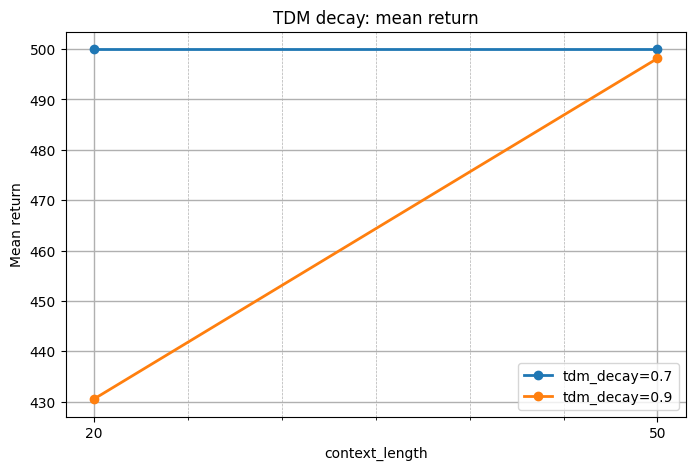

In [24]:
plt.figure(figsize=(8, 5))

for decay, sub in tdm_decay.groupby("tdm_decay"):
    sub = sub.sort_values("context_length")
    plt.plot(
        sub["context_length"],
        sub["mean_return"],
        marker="o",
        linewidth=2,
        label=f"tdm_decay={decay}",
    )

plt.xlabel("context_length")
plt.ylabel("Mean return")
plt.title("TDM decay: mean return")

plt.xticks([20, 50])
plt.gca().set_xticks(np.arange(20, 51, 5), minor=True)

plt.grid(True, which="major", linewidth=1)
plt.grid(True, which="minor", linestyle="--", linewidth=0.5)

plt.legend()
plt.show()

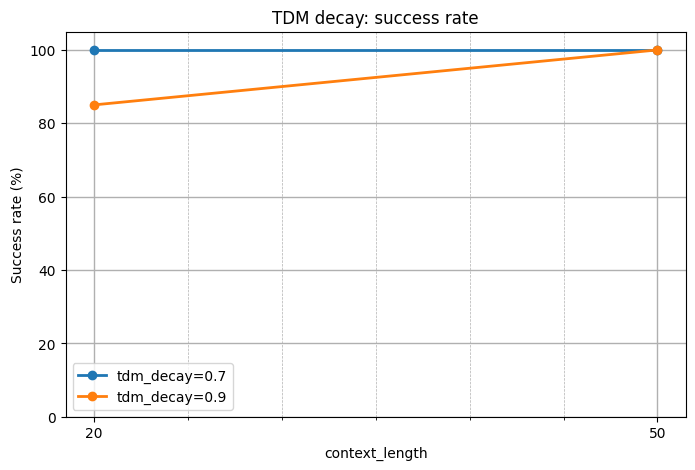

In [25]:
plt.figure(figsize=(8, 5))

for decay, sub in tdm_decay.groupby("tdm_decay"):
    sub = sub.sort_values("context_length")
    plt.plot(
        sub["context_length"],
        sub["success_rate"] * 100,
        marker="o",
        linewidth=2,
        label=f"tdm_decay={decay}",
    )

plt.xlabel("context_length")
plt.ylabel("Success rate (%)")
plt.title("TDM decay: success rate")

plt.xticks([20, 50])
plt.gca().set_xticks(np.arange(20, 51, 5), minor=True)

plt.ylim(0, 105)
plt.grid(True, which="major", linewidth=1)
plt.grid(True, which="minor", linestyle="--", linewidth=0.5)

plt.legend()
plt.show()

Качество работы TDM сильно зависит от параметра `tdm_decay`.

При `context_length = 20` модель с `tdm_decay = 0.9` работает заметно хуже: mean return равен 430.5, а success rate равен 85%. Это означает, что память обновляется слишком медленно и не успевает достаточно хорошо использовать изменения состояния внутри окна длины 20.

Модель с `tdm_decay = 0.7` достигает return 500 и 100% success rate уже при `context_length = 20`. Значит, более быстрое обновление памяти оказалось лучше для этой среды.

При `context_length = 50` обе версии TDM работают хорошо, но `tdm_decay = 0.7` всё равно даёт немного более стабильный результат.

## Выводы

В работе были реализованы и сравнены несколько вариантов Decision Transformer для `VelocityCartPoleEnv`: стандартный DT без явной памяти, DT+GRU, DT+LSTM и собственный механизм памяти TDM.

Эксперименты показывают, что добавление памяти в целом делает модель более устойчивой. Это особенно заметно при уменьшении размера offline dataset и при изменении длины context window. Стандартный DT хорошо работает на полном датасете, но хуже переносит уменьшение количества данных. GRU и LSTM дают более стабильное качество при разных настройках. TDM после настройки `tdm_decay = 0.7` тоже достигает высокого качества и показывает, что простая специализированная память, основанная на изменениях состояния, может быть эффективной для этой POMDP-среды.

При этом результаты нужно интерпретировать весьма осторожно. В полном датасете почти все сильные модели быстро достигают return около максимума в 500. Это значит, что задача в данной постановке частично слишком лёгкая для точного сравнения моделей: dataset состоит из качественных trajectories, а `VelocityCartPoleEnv` хорошо решается уже стандартным DT при некоторых настройках.

Поэтому наиболее информативными оказались не только финальные метрики на полном датасете, но и дополнительные проверки: уменьшение размера датасета, изменение context length, RTG ablation и графики обучения. Именно в этих экспериментах лучше видны различия между подходами.

В целом, GRU и LSTM можно считать наиболее стабильными стандартными вариантами памяти. TDM оказалась более чувствительной к настройкам, но после выбора подходящего `tdm_decay` стала конкурентоспособной.